# FusionSolar northbound API demo

This notebook walks through the Huawei FusionSolar SmartPVMS northbound API against
`https://eu5.fusionsolar.huawei.com`, ending with a snapshot of PV production, grid
export, and household consumption.

**API documentation**

- [Authentication API](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/9676f1cf/authentication-api)
- [Basic APIs](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/baf43abb/basic)
- [Monitoring](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/b9df65c2/monitoring)

**Limits**

- XSRF token lifetime: 30 minutes after login.
- Login: 5 calls per 10 minutes ([Authentication API](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/9676f1cf/authentication-api)).
- Realtime device data: 1 call per `devTypeId` per 5 minutes ([flow control](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/b71c4d05/flow-control-using-the-api-account)).
- Historical device data: one device per call, max 24 hours per call; 1 call per 300 seconds for one inverter and one meter ([monitoring](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/b9df65c2/monitoring), [flow control](https://support.huawei.com/enterprise/en/doc/EDOC1100544235/b71c4d05/flow-control-using-the-api-account)).
- The client enforces these limits and logs waits via loguru.

## Setup

Set credentials via environment variables (see `.env.example` in the project root).
Do not commit secrets or notebook outputs that contain tokens.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import json

import matplotlib
import pandas as pd

from darb_solar import FusionSolarClient
from darb_solar.fusionsolar import (
    DEFAULT_BASE_URL,
    device_dn,
    active_power_kw_from_realtime_kpi,
    filter_inverters,
    filter_meters,
    active_power_kw_from_history_record,
)
from darb_solar.time import (
    DEFAULT_TIMEZONE,
    datetime_from_epoch_ms,
    datetime_to_epoch_ms,
    day_bounds_epoch_ms,
)
from darb_solar.env import load_env

# Optional: load from a .env file if python-dotenv is installed locally.
# from dotenv import load_dotenv
load_env()

USERNAME = os.environ["FUSIONSOLAR_USERNAME"]
SYSTEM_CODE = os.environ["FUSIONSOLAR_SYSTEM_CODE"]
BASE_URL = os.environ.get("FUSIONSOLAR_BASE_URL", DEFAULT_BASE_URL)
EXPECTED_PLANT_CODE = "NE=182468888"

client = FusionSolarClient(base_url=BASE_URL)
print(f"Client ready for {BASE_URL}")

## Authentication

Login returns an `xsrf-token` response header. The client stores it for subsequent
calls.

In [ ]:
token = client.login(USERNAME, SYSTEM_CODE)
print(f"Logged in. Token prefix: {token[:8]}… (length {len(token)})")

## Stations

List plants and locate the expected `plantCode`.

In [ ]:
stations_data = client.list_stations(page_no=1)
stations_df = pd.DataFrame(stations_data["list"])
display(stations_df)

matching = stations_df.loc[
    stations_df["plantCode"] == EXPECTED_PLANT_CODE,
    "plantCode",
]
if matching.empty:
    raise ValueError(f"Plant {EXPECTED_PLANT_CODE} not found on page 1")
print(f"Found plant: {EXPECTED_PLANT_CODE}")

## Device list

Fetch devices for the plant and pick the first inverter and power-sensor meter.
Inverter types: `1` (string) or `38` (residential). Meter type: `47` (power sensor;
some installs use grid meter type `17` instead).

In [ ]:
devices = client.list_devices(EXPECTED_PLANT_CODE)
devices_df = pd.DataFrame(devices)[
    ["id", "devDn", "devName", "devTypeId", "model"]
]
display(devices_df)

inverters = filter_inverters(devices)
meters = filter_meters(devices)
if not inverters:
    raise ValueError("No inverter found (devTypeId 1 or 38)")
if not meters:
    raise ValueError("No power-sensor meter found (devTypeId 47)")

inverter = inverters[0]
meter = meters[0]
print(
    f"Inverter: {inverter['devName']} (devDn={device_dn(inverter)}, "
    f"devTypeId={inverter['devTypeId']})"
)
print(
    f"Meter: {meter['devName']} (devDn={device_dn(meter)}, "
    f"devTypeId={meter['devTypeId']})"
)

## Realtime KPI

Query live KPI for the inverter and meter. Inverter `active_power` is reported in
kW. Meter `active_power` is reported in W (types `47` and `17`); use
`active_power_kw_from_realtime_kpi` to convert to kW. Positive meter values mean grid export.

In [ ]:
inverter_kpi = client.get_device_real_kpi(
    inverter["id"],
    inverter["devTypeId"],
)
meter_kpi = client.get_device_real_kpi(
    meter["id"],
    meter["devTypeId"],
)

for label, kpi in [("Inverter", inverter_kpi), ("Meter", meter_kpi)]:
    retrieved_at = datetime_from_epoch_ms(kpi.current_time_ms)
    if retrieved_at is not None:
        print(f"{label} data retrieved at: {retrieved_at.isoformat()}")
    else:
        print(f"{label} data retrieved at: unknown")

print("Inverter dataItemMap:", json.dumps(
    inverter_kpi.devices[0]["dataItemMap"], sort_keys=True, indent=4)
     )
print("Meter dataItemMap:", json.dumps(
    meter_kpi.devices[0]["dataItemMap"], sort_keys=True, indent=4)
     )

inverter_kw = active_power_kw_from_realtime_kpi(
    inverter_kpi, inverter["id"], inverter["devTypeId"]
)
meter_kw = active_power_kw_from_realtime_kpi(
    meter_kpi, meter["id"], meter["devTypeId"]
)
meter_raw_w = float(meter_kpi.devices[0]["dataItemMap"]["active_power"])
print(f"Inverter active_power: {inverter_kw:.3f} kW")
print(f"Meter active_power: {meter_raw_w:.1f} W ({meter_kw:.3f} kW)")

> This is really the real time data. On the FusionSolar app, the real time data is shown every 5 minutes: 9:40, 9:45, 9:50 etc.

## Energy balance

| Metric | Source | Meaning |
|--------|--------|---------|
| PV production | inverter `active_power` (kW) | Current solar output |
| Grid export | meter `active_power` when positive (kW, converted from W) | Power sent to grid |
| Consumption | `inverter - meter` (kW) | Household load |

In [ ]:
balance = FusionSolarClient.compute_energy_balance(inverter_kw, meter_kw)

summary_df = pd.DataFrame(
    [
        {
            "metric": "PV production",
            "value_kw": balance.pv_production_kw,
            "source": "inverter active_power (kW)",
        },
        {
            "metric": "Grid export",
            "value_kw": balance.grid_export_kw,
            "source": "meter active_power W → kW, when exporting",
        },
        {
            "metric": "Consumption",
            "value_kw": balance.consumption_kw,
            "source": "inverter - meter (kW)",
        },
    ]
)
display(summary_df)

## Notes

- This notebook makes **5 API calls** for the realtime section (login, stations,
  devices, two KPI queries). Historical queries add two more calls (one per
  device) with a client-enforced wait between them.
- Realtime KPI values reflect the last collection cycle; Huawei enforces a minimum
  5-minute interval between realtime reads per device type.
- Historical data is returned at 5-minute intervals; each call covers one device
  and at most 24 hours. Use `get_device_history_range` for longer spans.
- Avoid repeated logins: the API allows only 5 login attempts per 10 minutes.
- Re-run the KPI and balance cells for updated snapshots without re-authenticating
  while the token remains valid (30 minutes).
- Meter `active_power` is in W in the API response; always convert before combining
  with inverter readings (kW).

## Historical KPI

Fetch today's 5-minute history for the inverter and meter. The historical API
uses `devDn` (not `id`) and returns `dataItems` rows with `collectTime`
timestamps.

In [ ]:
from datetime import datetime

history_start_ms, history_end_ms = day_bounds_epoch_ms(datetime.now(DEFAULT_TIMEZONE))

inverter_history = client.get_device_history(
    device_dn(inverter),
    inverter["devTypeId"],
    history_start_ms,
    history_end_ms,
)
meter_history = client.get_device_history(
    device_dn(meter),
    meter["devTypeId"],
    history_start_ms,
    history_end_ms,
)

print(f"Inverter history rows: {len(inverter_history.records)}")
print(f"Meter history rows: {len(meter_history.records)}")

In [ ]:
def history_to_series(
    records: list[dict],
    dev_type_id: int,
) -> pd.Series:
    rows = {}
    for record in records:
        collected_at = datetime_from_epoch_ms(int(record["collectTime"]))
        rows[collected_at] = active_power_kw_from_history_record(record, dev_type_id)
    return pd.Series(rows, name="active_power_kw").sort_index()


pv_output_kw = history_to_series(
    inverter_history.records,
    int(inverter["devTypeId"]),
)
meter_kw = history_to_series(
    meter_history.records,
    int(meter["devTypeId"]),
)

pv_output_kw, meter_kw = pv_output_kw.align(meter_kw, join="outer", fill_value=0.0)

plot_df = pd.DataFrame(
    {
        "PV output": pv_output_kw,
        "Total consumption": pv_output_kw - meter_kw,
    }
)
display(plot_df.tail(12))

ax = plot_df.plot(
    figsize=(12, 4),
    title="Active power today (kW)",
    color=["green", "red"],
)
ax.set_ylabel("kW")

> For some reason the first consumption pic does match the one in FusionSolar.

## Validate against local database

After running `scripts/bootstrap_plant.py` and syncing history for today
(`scripts/sync_fusionsolar_history.py --from-date today --to-date today`),
the same 5-minute curves can be loaded from SQLite and compared to the live
API response above. Small differences may appear when the DB was synced at a
different time than this notebook run.

In [ ]:
from datetime import datetime, timedelta

from darb_solar.db import get_connection, list_device_power_readings, list_devices


def readings_to_series(readings: list) -> pd.Series:
    return pd.Series(
        {
            pd.Timestamp(reading["collected_at"]): reading["active_power_kw"]
            for reading in readings
        },
        name="active_power_kw",
    ).sort_index()


day_start = datetime.now(DEFAULT_TIMEZONE).replace(
    hour=0, minute=0, second=0, microsecond=0
)
day_end = day_start + timedelta(days=1)
collected_from = day_start.isoformat()
collected_to = day_end.isoformat()

with get_connection() as connection:
    db_devices = {
        device["role"]: device
        for device in list_devices(connection, plant_code=EXPECTED_PLANT_CODE)
    }
    if len(db_devices) < 2:
        raise RuntimeError(
            "Run scripts/bootstrap_plant.py and sync history before validating."
        )
    db_inverter_readings = list_device_power_readings(
        connection,
        dev_id=db_devices["inverter"]["dev_id"],
        collected_from=collected_from,
        collected_to=collected_to,
    )
    db_meter_readings = list_device_power_readings(
        connection,
        dev_id=db_devices["meter"]["dev_id"],
        collected_from=collected_from,
        collected_to=collected_to,
    )

print(
    f"DB inverter rows: {len(db_inverter_readings)}, "
    f"meter rows: {len(db_meter_readings)}"
)

db_pv_kw = readings_to_series(db_inverter_readings)
db_meter_kw = readings_to_series(db_meter_readings)
db_pv_kw, db_meter_kw = db_pv_kw.align(db_meter_kw, join="outer", fill_value=0.0)

db_plot_df = pd.DataFrame(
    {
        "PV output": db_pv_kw,
        "Total consumption": db_pv_kw - db_meter_kw,
    }
)
display(db_plot_df.tail(12))

common_times = plot_df.index.intersection(db_plot_df.index)
if common_times.empty:
    print("No overlapping timestamps between API and DB for today.")
else:
    diff_df = pd.DataFrame(
        {
            "PV output Δ": (
                plot_df.loc[common_times, "PV output"]
                - db_plot_df.loc[common_times, "PV output"]
            ),
            "Consumption Δ": (
                plot_df.loc[common_times, "Total consumption"]
                - db_plot_df.loc[common_times, "Total consumption"]
            ),
        }
    )
    print(
        f"Overlapping points: {len(common_times)} "
        f"(API {len(plot_df)}, DB {len(db_plot_df)})"
    )
    print(
        "Max |Δ| kW — PV:"
        f" {diff_df['PV output Δ'].abs().max():.6f},"
        " consumption:"
        f" {diff_df['Consumption Δ'].abs().max():.6f}"
    )
    display(diff_df.abs().sort_values("PV output Δ", ascending=False).head(5))

In [ ]:
import matplotlib.pyplot as plt

overlay_df = pd.DataFrame(
    {
        "PV output (API)": plot_df["PV output"],
        "PV output (DB)": db_plot_df["PV output"],
        "Consumption (API)": plot_df["Total consumption"],
        "Consumption (DB)": db_plot_df["Total consumption"],
    }
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

overlay_df[["PV output (API)", "PV output (DB)"]].plot(
    ax=axes[0],
    style=["-", "--"],
    color=["green", "darkgreen"],
    title="PV output — API vs DB",
)
axes[0].set_ylabel("kW")

overlay_df[["Consumption (API)", "Consumption (DB)"]].plot(
    ax=axes[1],
    style=["-", "--"],
    color=["red", "darkred"],
    title="Consumption — API vs DB",
)
axes[1].set_ylabel("kW")
fig.tight_layout()

# TODO
- [x] Plot the same curve as the FusionSolar dashboard and compare
- [x] Data pipeline for collecting historical data
- [x] Compare total energy for a given day and fractions with UI -> not exactly equal
- [x] Prototype streamlit app
- [x] Add total consumption inside the pie chart
- [x] Update imports to match the new refactor
- [x] App: plot kWh groupement par heure ?
- [x] Time zone from the CLI != time zone
- [x] Design real time data pipeline (first intraday)
- [x] Fix `launchd` script writing data until 3AM only
- [x] Add retries for read time out error `(2026-06-26 10:16:55.307 | ERROR    | darb_solar.history_sync.sync:sync_device_day_window:415 - Failed dev_id=1000000182468892 day=2026-06-24: HTTPSConnectionPool(host='eu5.fusionsolar.huawei.com', port=443): Read timed out. (read timeout=30)`
- [x] Add retries for `2026-06-29 10:56:21.095 | ERROR    | darb_solar.intraday_sync.sync:sync_device_intraday:132 - Intraday sync failed dev_id=1000000182468898: USER_MUST_RELOGIN (failCode=305)`
- [x] If the user updates the history in the middle of a day, it means part of the history for that day will be written. When he wants to update later, it won't be possible because of the checkpoint already existing -> ok for now
- [ ] Design data pipeline in the cloud
- [ ] Design hosting in the cloud
- [ ] Clean scripts
- [ ] Clean streamlit code (transformation of data "self_consumed" ? when ?) 
- [ ] Collect historical data over 2026
- [ ] Do we really need 5 minutes intervals between two history queries ?

Fix:
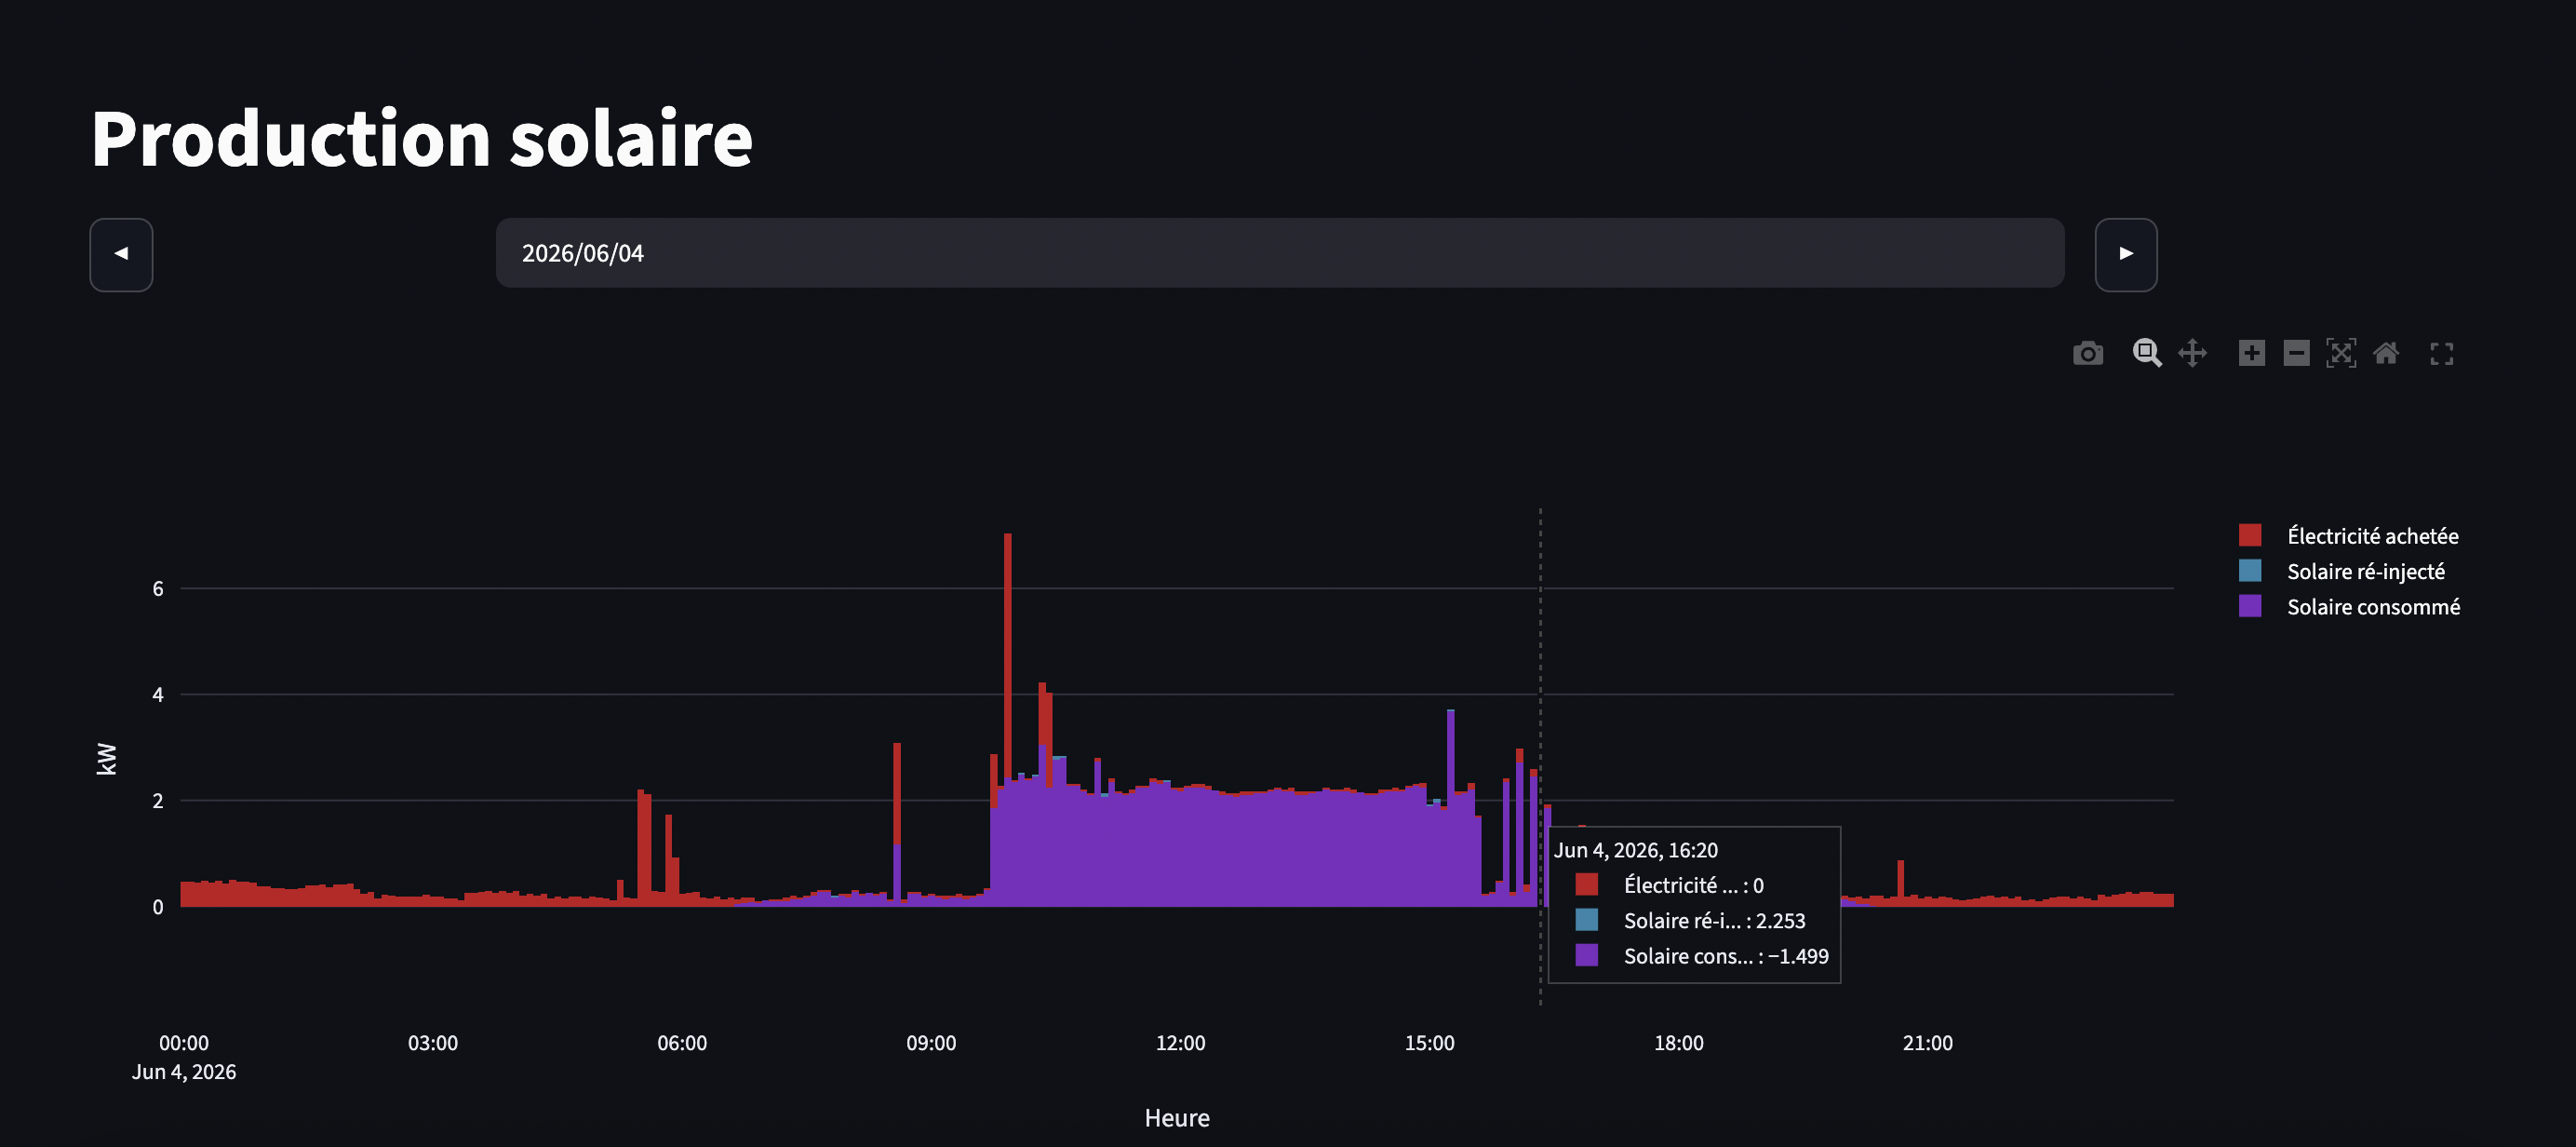

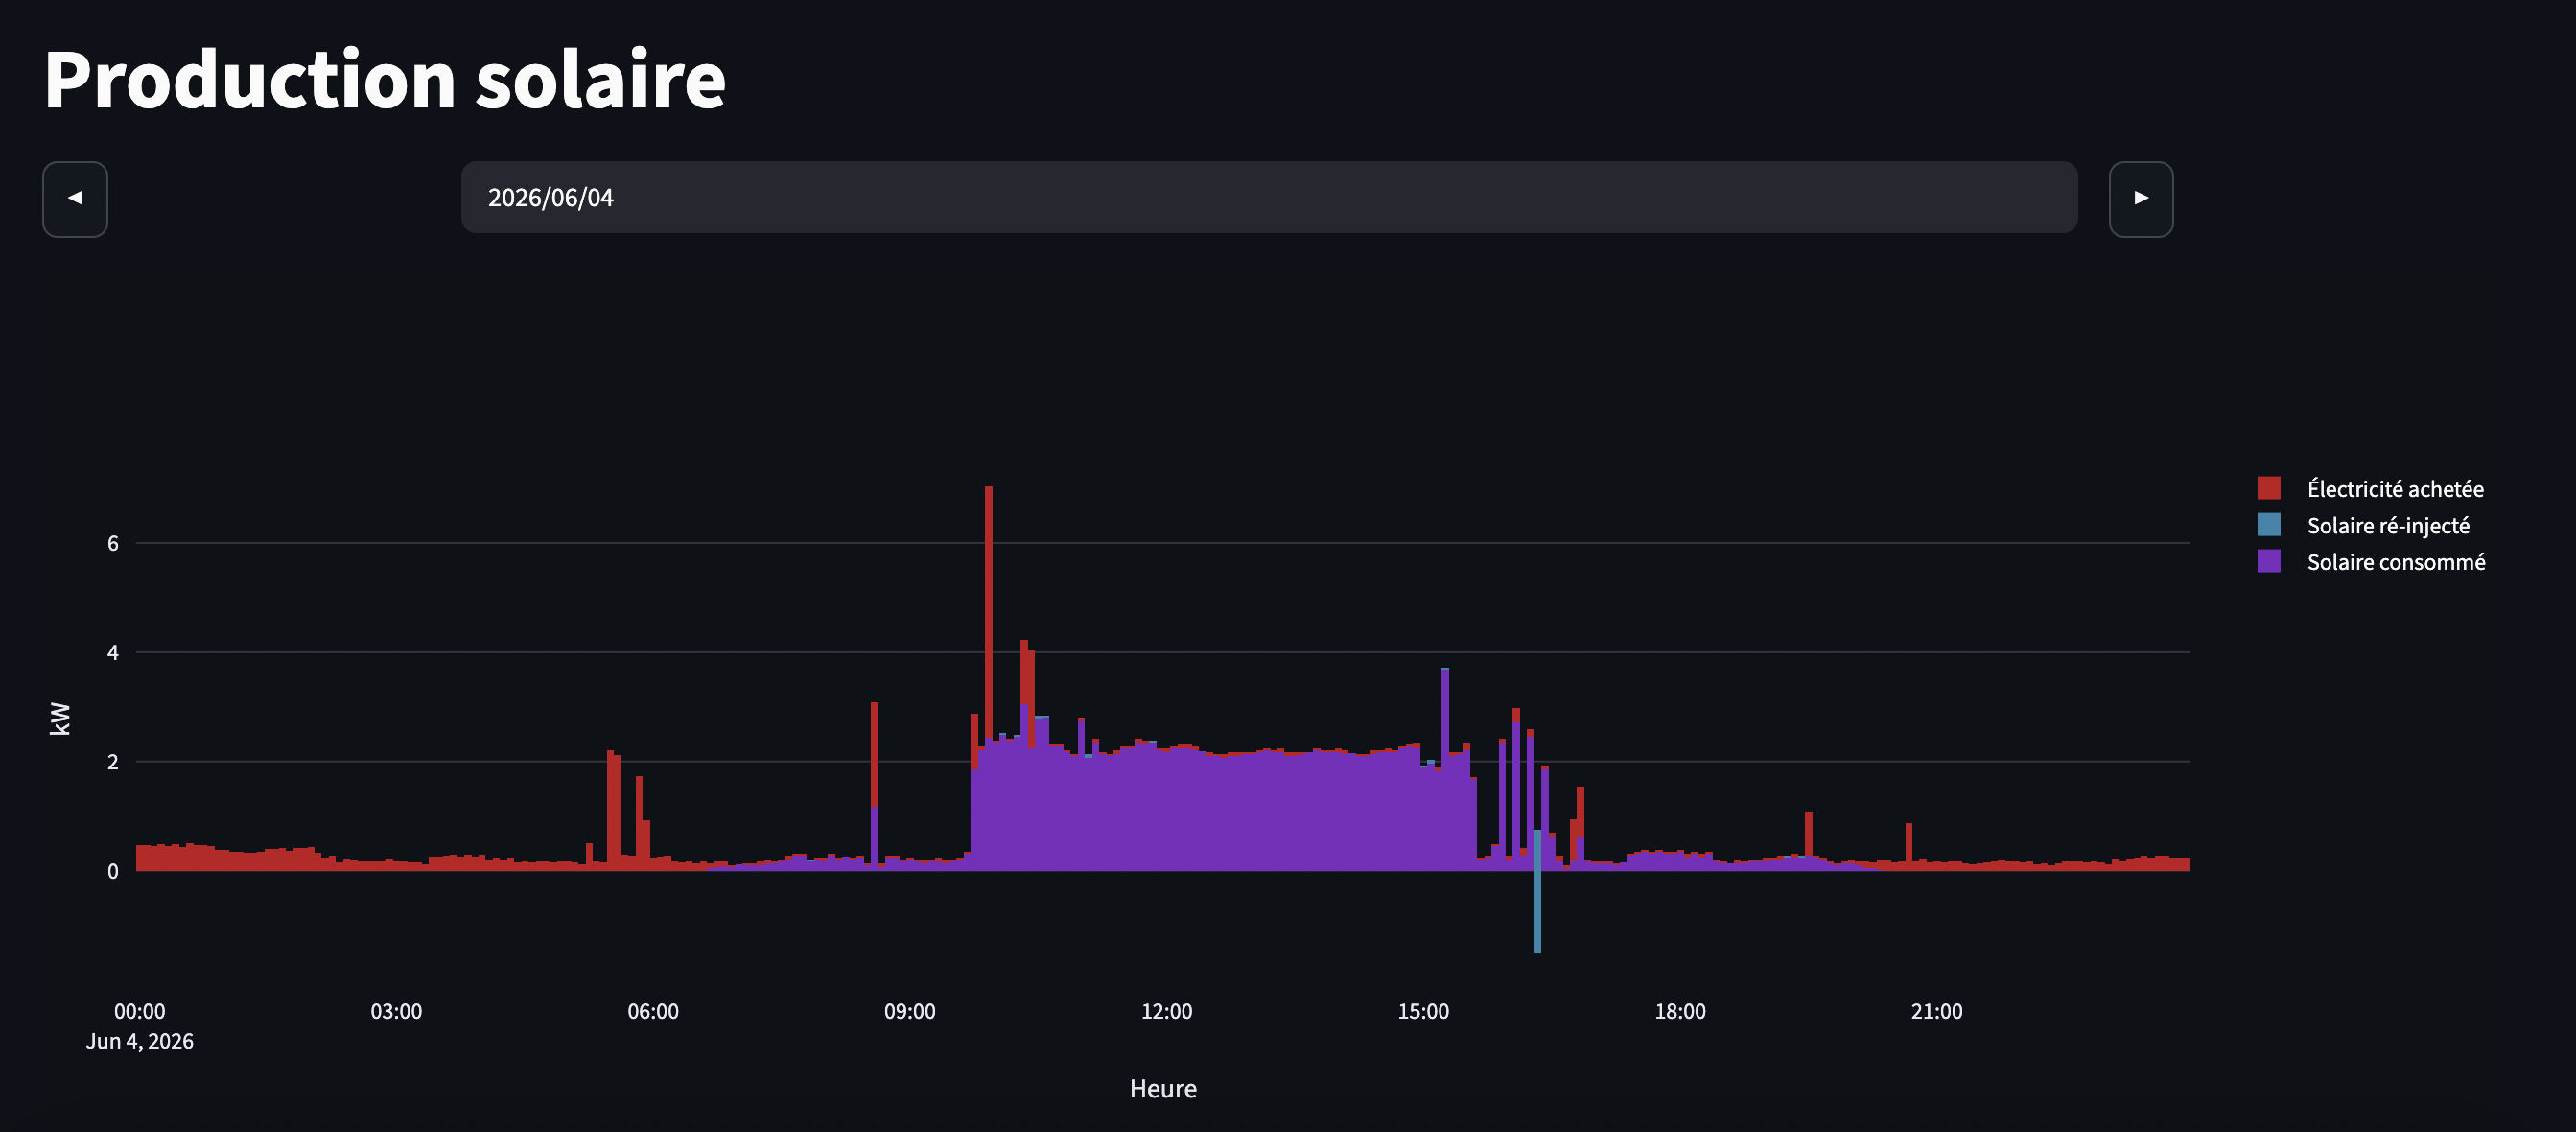

- When comparing the total energy consumption on a given day, e.g. 24/06/2026, we get similar values as in the FusionSolar app but not exactly the same:
13,68 kWh (solar), 6.76 kWh (grid) as from `darb-solar`, compared to 13.75 kWh (solar), 6.84 kWh (grid) as for FusionSolar.

In [ ]:
interval_1 = 0.4
interval_2 = 0.3
production_a = (interval_1 + interval_2)*5/60
production_b = interval_1*60/5 + interval_2*60/5

In [ ]:
production_a

In [ ]:
production_b